# Feature Importance Evolution Analysis

This notebook analyzes how feature importance rankings evolve over time during walk-forward training.

**Key Visualizations:**
- Rank evolution heatmap for top features
- Feature importance trends over time
- Feature stability metrics
- Top 20 features ranking changes

**Configuration:**
- Set `FOCUS_ON_FUNDAMENTALS = True` in cell 1 to exclude price/market cap features (RefPriceClose_lag1, CompanyMarketCap_lag1) and focus on fundamental feature analysis

## 1. Setup and Imports

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GLOBAL CONFIGURATION FLAGS
# ============================================================================

# Set to True to exclude price/market cap lagged features and focus on fundamentals
FOCUS_ON_FUNDAMENTALS = True

# Features to exclude when FOCUS_ON_FUNDAMENTALS = True
# These are price-derived features, not fundamental company metrics
EXCLUDED_PRICE_FEATURES = [
    'RefPriceClose_lag1',
    'CompanyMarketCap_lag1',
    'CompanyMarketCap_lag1_rank',
    'volatility_20d',           # Price volatility (not fundamental)
    'volatility_20d_rank',      # Ranking of volatility (not fundamental)
]

# ============================================================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Figure settings
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Imports complete")
if FOCUS_ON_FUNDAMENTALS:
    print(f"🎯 FOCUS MODE: Excluding {len(EXCLUDED_PRICE_FEATURES)} price/market cap features")
    for feat in EXCLUDED_PRICE_FEATURES:
        print(f"   ❌ {feat}")
else:
    print("📊 FULL MODE: Analyzing all features")

✅ Imports complete
🎯 FOCUS MODE: Excluding 5 price/market cap features
   ❌ RefPriceClose_lag1
   ❌ CompanyMarketCap_lag1
   ❌ CompanyMarketCap_lag1_rank
   ❌ volatility_20d
   ❌ volatility_20d_rank


## 2. Auto-Detect Latest Feature Importance File

In [229]:
def find_latest_feature_importance(directory='logs'):
    """
    Find the most recent feature_importance_*.csv file by timestamp in filename.
    
    Expected format: feature_importance_YYYYMMDD_HHMMSS.csv
    
    Returns:
        Path: Path to newest file
    """
    base_dir = Path('.') / directory
    pattern = 'feature_importance_*.csv'
    
    files = list(base_dir.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No {pattern} files found in {base_dir}")
    
    # Extract timestamp from filename: feature_importance_YYYYMMDD_HHMMSS.csv
    def extract_timestamp(filepath):
        stem = filepath.stem  # Remove .csv
        parts = stem.split('_')  # ['feature', 'importance', 'YYYYMMDD', 'HHMMSS']
        if len(parts) >= 4:
            date_str = parts[2]  # YYYYMMDD
            time_str = parts[3]  # HHMMSS
            timestamp_str = date_str + time_str
            return datetime.strptime(timestamp_str, '%Y%m%d%H%M%S')
        return datetime.min
    
    # Sort by timestamp (newest first)
    files_sorted = sorted(files, key=extract_timestamp, reverse=True)
    newest_file = files_sorted[0]
    
    print(f"📂 Found {len(files)} feature importance files")
    print(f"✅ Using newest: {newest_file.name}")
    print(f"   Timestamp: {extract_timestamp(newest_file).strftime('%Y-%m-%d %H:%M:%S')}")
    
    return newest_file

# Auto-detect latest file
feature_importance_file = find_latest_feature_importance()
print(f"\n📄 File path: {feature_importance_file}")

📂 Found 8 feature importance files
✅ Using newest: feature_importance_20260124_083504.csv
   Timestamp: 2026-01-24 08:35:04

📄 File path: logs/feature_importance_20260124_083504.csv


## 3. Load and Inspect Data

In [230]:
# Load feature importance data
df = pd.read_csv(feature_importance_file)

# Apply feature filtering if FOCUS_ON_FUNDAMENTALS is enabled
if FOCUS_ON_FUNDAMENTALS:
    original_count = len(df)
    original_features = df['Feature'].nunique()
    
    # Remove excluded features
    df = df[~df['Feature'].isin(EXCLUDED_PRICE_FEATURES)].copy()
    
    filtered_count = len(df)
    filtered_features = df['Feature'].nunique()
    
    print(f"🎯 FILTER APPLIED:")
    print(f"   Rows: {original_count:,} → {filtered_count:,} (-{original_count - filtered_count:,})")
    print(f"   Features: {original_features} → {filtered_features} (-{original_features - filtered_features})")
    print()

print(f"📊 Data Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"📅 Time Range: {df['Month'].min()} to {df['Month'].max()}")
print(f"🔢 Unique Months: {df['Month'].nunique()}")
print(f"🎯 Unique Features: {df['Feature'].nunique()}")
print(f"\n📋 Sample Data:")
df.head(20)

🎯 FILTER APPLIED:
   Rows: 3,860 → 3,163 (-697)
   Features: 183 → 178 (-5)

📊 Data Shape: 3,163 rows, 5 columns
📅 Time Range: 2010-01 to 2026-01
🔢 Unique Months: 193
🎯 Unique Features: 178

📋 Sample Data:


,Month,Rank,Feature,Importance,Std
0,2010-01,1,EnterpriseValue_DailyTimeSeries_,0.101846,0.004614
1,2010-01,2,PriceTarget_Median,0.095149,0.003802
2,2010-01,3,ForwardPriceToSalesPerShare_DailyTimeSeriesRatio_,0.091682,0.007710
3,2010-01,4,CashCashEquivalents_Total,0.072420,0.001053
4,2010-01,5,Estpricegrowth_percent,0.066664,0.002744
5,2010-01,6,EnterpriseValueToSales_DailyTimeSeriesRatio_,0.063016,0.001767
6,2010-01,7,GICSSectorName,0.053949,0.001124
7,2010-01,8,Debt_Total,0.052182,0.004078
8,2010-01,9,sharadar_sicindustry,0.043618,0.000529
9,2010-01,10,InterestExpense_NetofCapitalizedInterest,0.037747,0.004931


In [231]:
# Summary statistics
print("📈 Summary Statistics:\n")
print(f"Total months with data: {df['Month'].nunique()}")
print(f"Total unique features tracked: {df['Feature'].nunique()}")
print(f"Features per month: {df.groupby('Month')['Feature'].count().mean():.1f} (avg)")
print(f"Importance range: {df['Importance'].min():.6f} to {df['Importance'].max():.6f}")

# Top 10 most stable features (appear in top 20 most frequently)
top20_mask = df['Rank'] <= 20
feature_appearances = df[top20_mask]['Feature'].value_counts().head(10)
print(f"\n🏆 Top 10 Most Stable Features (appear in top 20 most frequently):\n")
for i, (feature, count) in enumerate(feature_appearances.items(), 1):
    pct = (count / df['Month'].nunique()) * 100
    print(f"{i:2d}. {feature:50s} - {count:3d}/{df['Month'].nunique()} months ({pct:5.1f}%)")

📈 Summary Statistics:

Total months with data: 193
Total unique features tracked: 178
Features per month: 16.4 (avg)
Importance range: 0.004753 to 0.497792

🏆 Top 10 Most Stable Features (appear in top 20 most frequently):

 1. sharadar_scalemarketcap                            - 173/193 months ( 89.6%)
 2. return_20d                                         - 141/193 months ( 73.1%)
 3. Estpricegrowth_percent                             - 132/193 months ( 68.4%)
 4. totalassets_fmp                                    - 125/193 months ( 64.8%)
 5. EnterpriseValue_DailyTimeSeries_                   - 109/193 months ( 56.5%)
 6. GICSSectorName                                     - 107/193 months ( 55.4%)
 7. roa_rank                                           - 107/193 months ( 55.4%)
 8. roe_rank                                           - 100/193 months ( 51.8%)
 9. debt_to_marketcap                                  -  87/193 months ( 45.1%)
10. totalliabilities_fmp                       

## 4. Feature Ranking Evolution Heatmap

This heatmap shows how the rankings of top features change over time. Darker colors indicate better (lower) ranks.

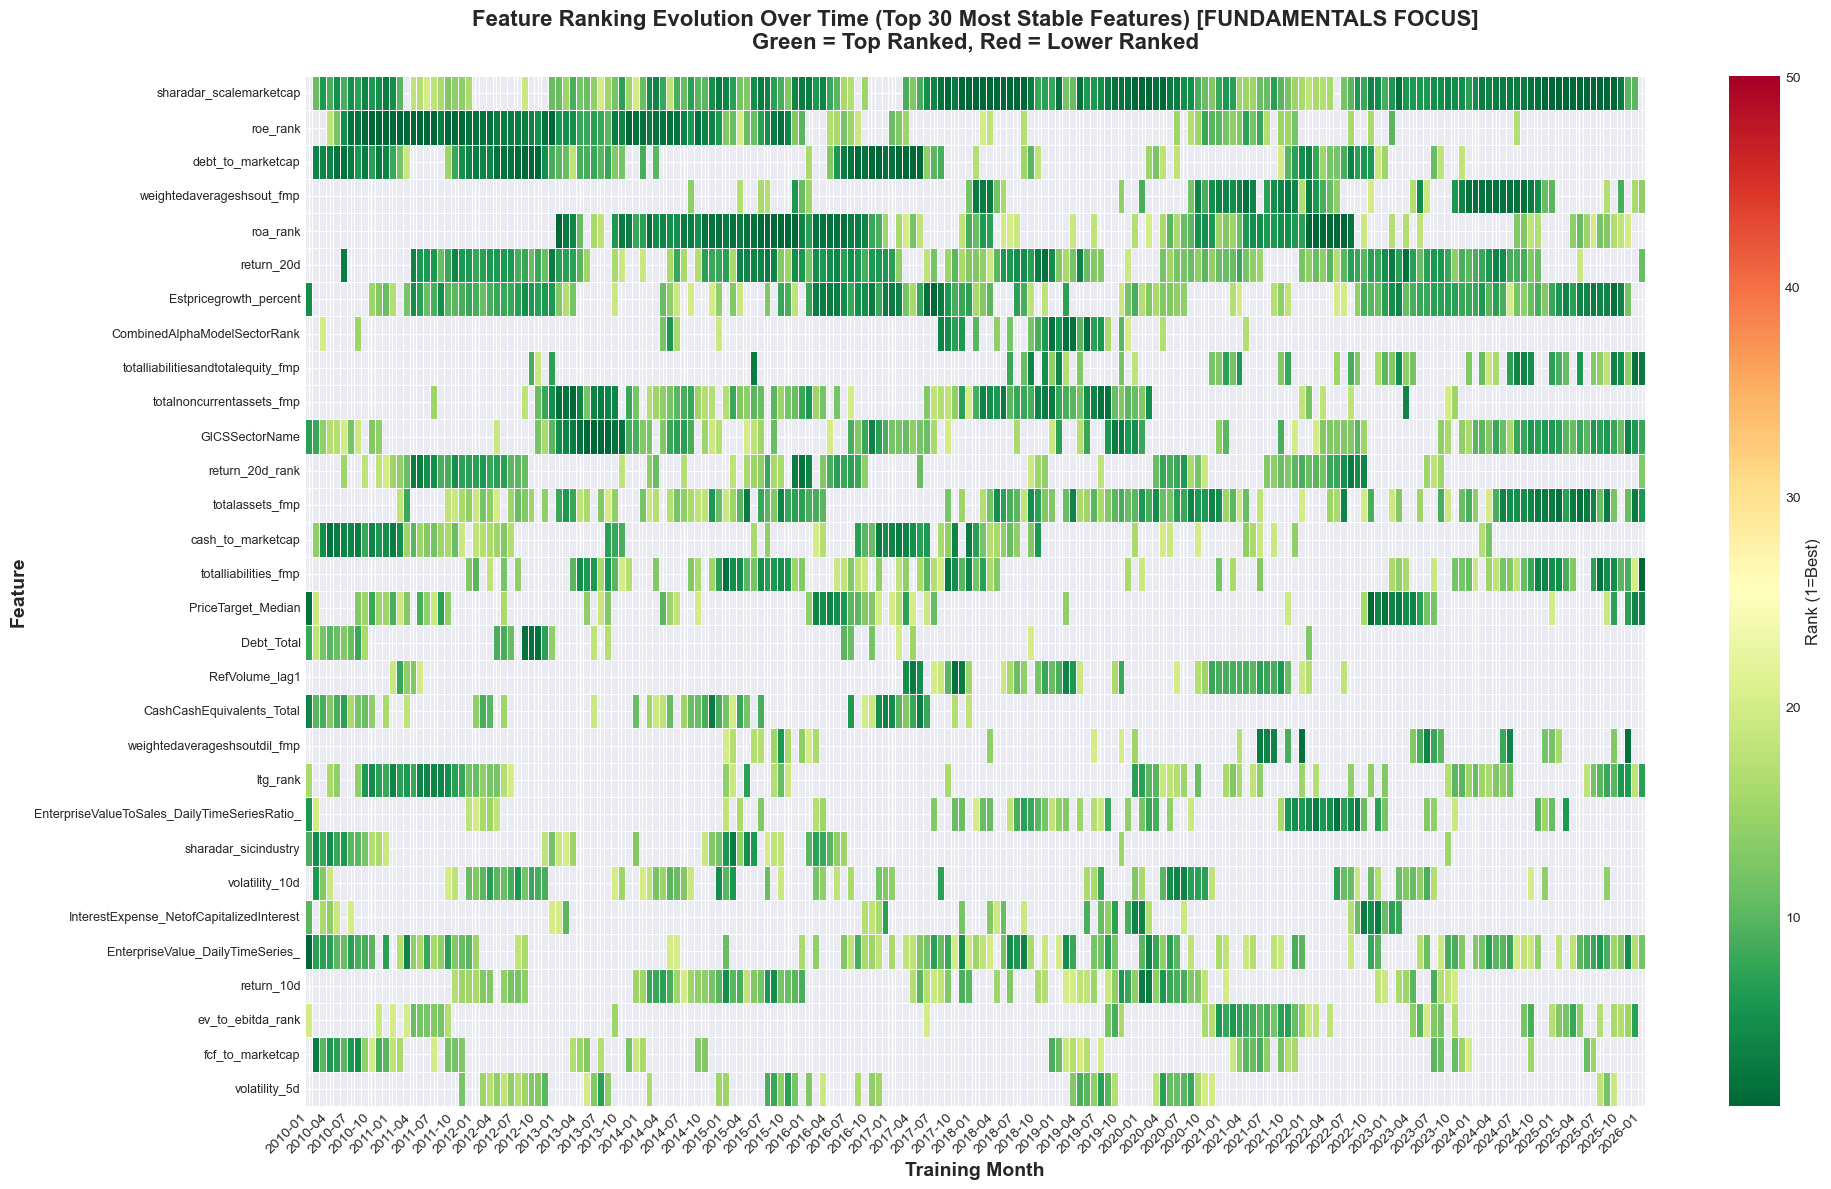


💡 Interpretation:
   • Green bands = Feature is highly ranked (important) in those months
   • Red bands = Feature rank dropped (less important)
   • White/missing = Feature not in top 50 for that month
   • Horizontal consistency = Stable feature importance
   • Vertical changes = Market regime shifts


In [232]:
# Get top N features that appear most frequently in top 20
N_TOP_FEATURES = 30
top20_mask = df['Rank'] <= 20
top_features = df[top20_mask]['Feature'].value_counts().head(N_TOP_FEATURES).index.tolist()

# Filter data for these features
df_top = df[df['Feature'].isin(top_features)].copy()

# Pivot to create heatmap data (Month x Feature)
heatmap_data = df_top.pivot(index='Feature', columns='Month', values='Rank')

# Sort features by average rank
heatmap_data['avg_rank'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('avg_rank')
heatmap_data = heatmap_data.drop('avg_rank', axis=1)

# Create heatmap
fig, ax = plt.subplots(figsize=(20, 12))

# Reverse colormap so dark = better rank (lower number)
sns.heatmap(heatmap_data, 
            cmap='RdYlGn_r',  # Red (bad/high rank) to Green (good/low rank)
            annot=False,
            fmt='.0f',
            cbar_kws={'label': 'Rank (1=Best)'},
            linewidths=0.5,
            vmin=1,
            vmax=50,
            ax=ax)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Ranking Evolution Over Time (Top {N_TOP_FEATURES} Most Stable Features){mode_text}\n' +
             f'Green = Top Ranked, Red = Lower Ranked',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Green bands = Feature is highly ranked (important) in those months")
print(f"   • Red bands = Feature rank dropped (less important)")
print(f"   • White/missing = Feature not in top 50 for that month")
print(f"   • Horizontal consistency = Stable feature importance")
print(f"   • Vertical changes = Market regime shifts")

## 5. Top 20 Features - Rank Position Over Time

Line chart showing how the top 20 most stable features move in ranking over time.

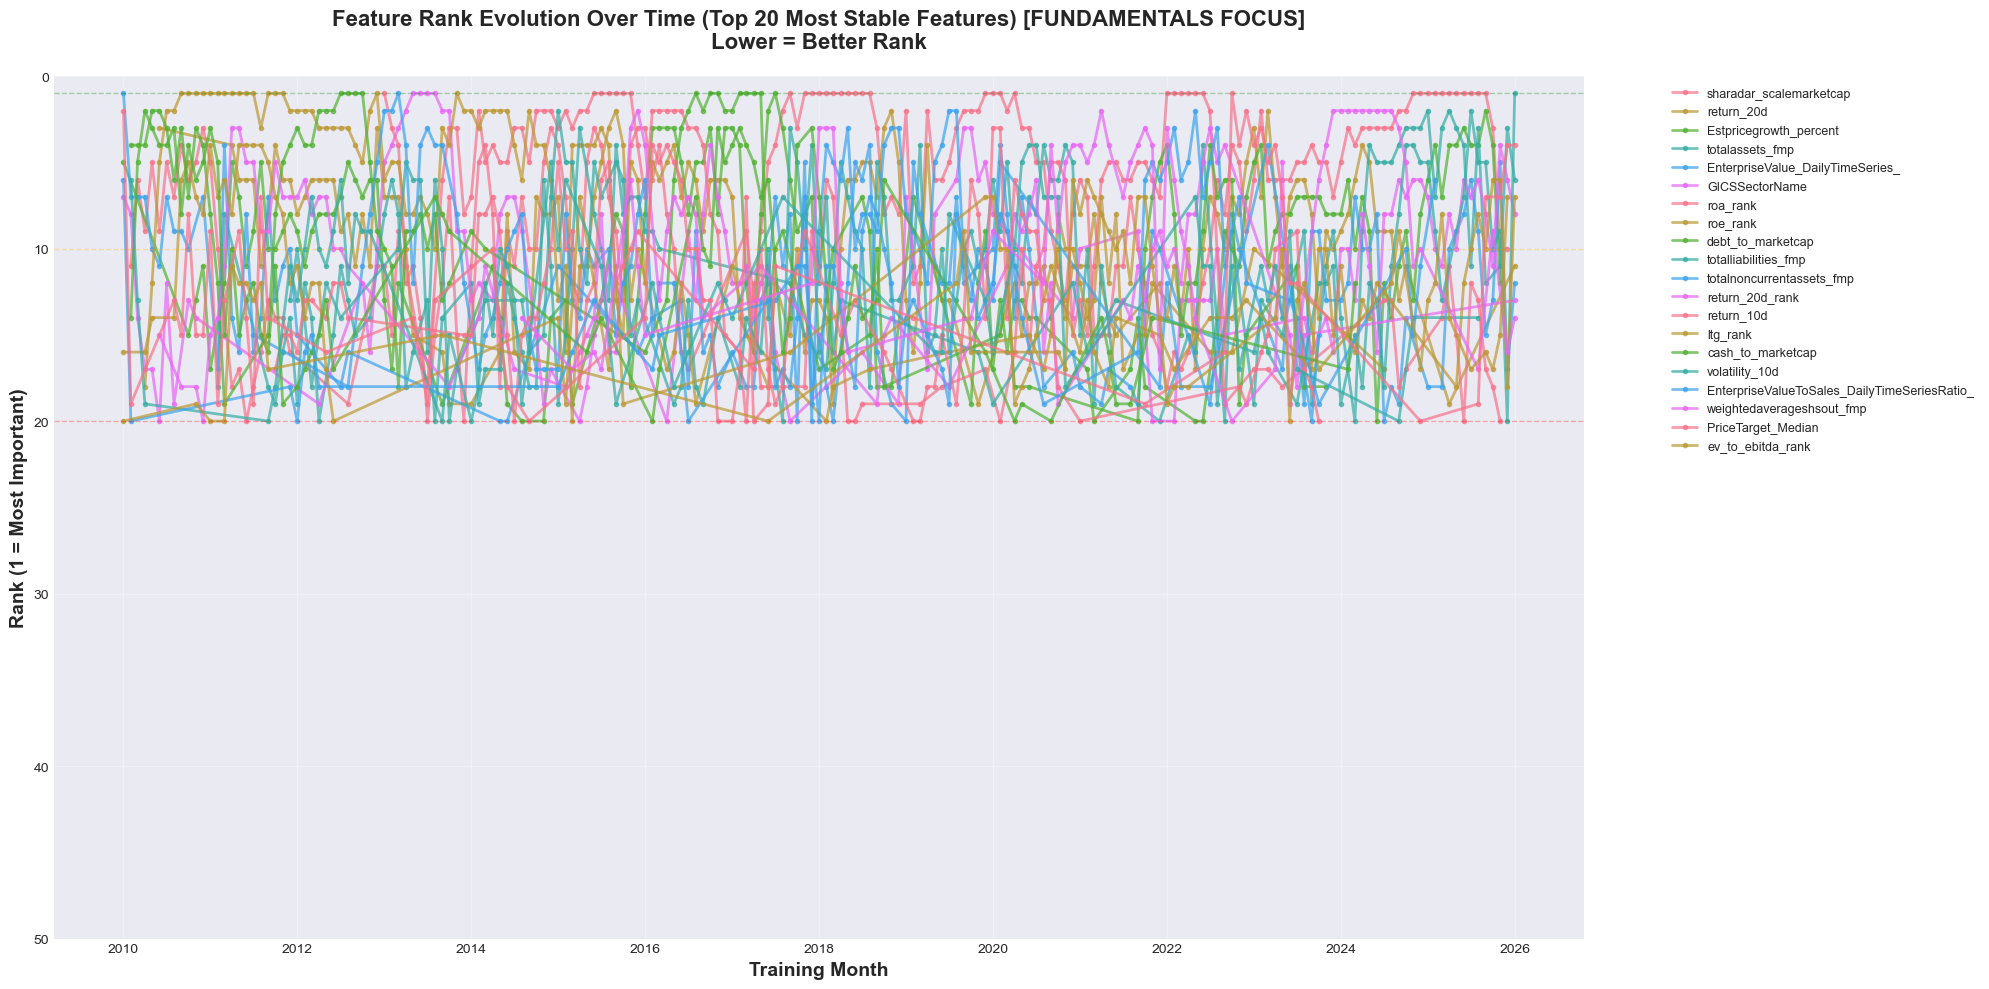


💡 Interpretation:
   • Lines closer to top (rank 1) = More important features
   • Flat lines = Stable importance over time
   • Sharp changes = Feature importance shifts (market regime change)


In [233]:
# Get top 20 most stable features
N_FEATURES_PLOT = 20
top20_mask = df['Rank'] <= 20
stable_features = df[top20_mask]['Feature'].value_counts().head(N_FEATURES_PLOT).index.tolist()

# Filter data
df_stable = df[df['Feature'].isin(stable_features)].copy()

# Convert Month to datetime for better plotting
df_stable['MonthDate'] = pd.to_datetime(df_stable['Month'] + '-01')

# Create plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot each feature as a line
for feature in stable_features:
    feature_data = df_stable[df_stable['Feature'] == feature].sort_values('MonthDate')
    ax.plot(feature_data['MonthDate'], 
            feature_data['Rank'],
            marker='o',
            markersize=3,
            linewidth=2,
            label=feature,
            alpha=0.7)

# Invert y-axis (rank 1 at top)
ax.invert_yaxis()
ax.set_ylim(50, 0)

# Add horizontal lines for reference
ax.axhline(y=1, color='green', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=20, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Rank Evolution Over Time (Top {N_FEATURES_PLOT} Most Stable Features){mode_text}\n' +
             'Lower = Better Rank',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Rank (1 = Most Important)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Lines closer to top (rank 1) = More important features")
print(f"   • Flat lines = Stable importance over time")
print(f"   • Sharp changes = Feature importance shifts (market regime change)")

## 6. Feature Importance Score Over Time

Shows absolute importance scores (not just ranks) for top features.

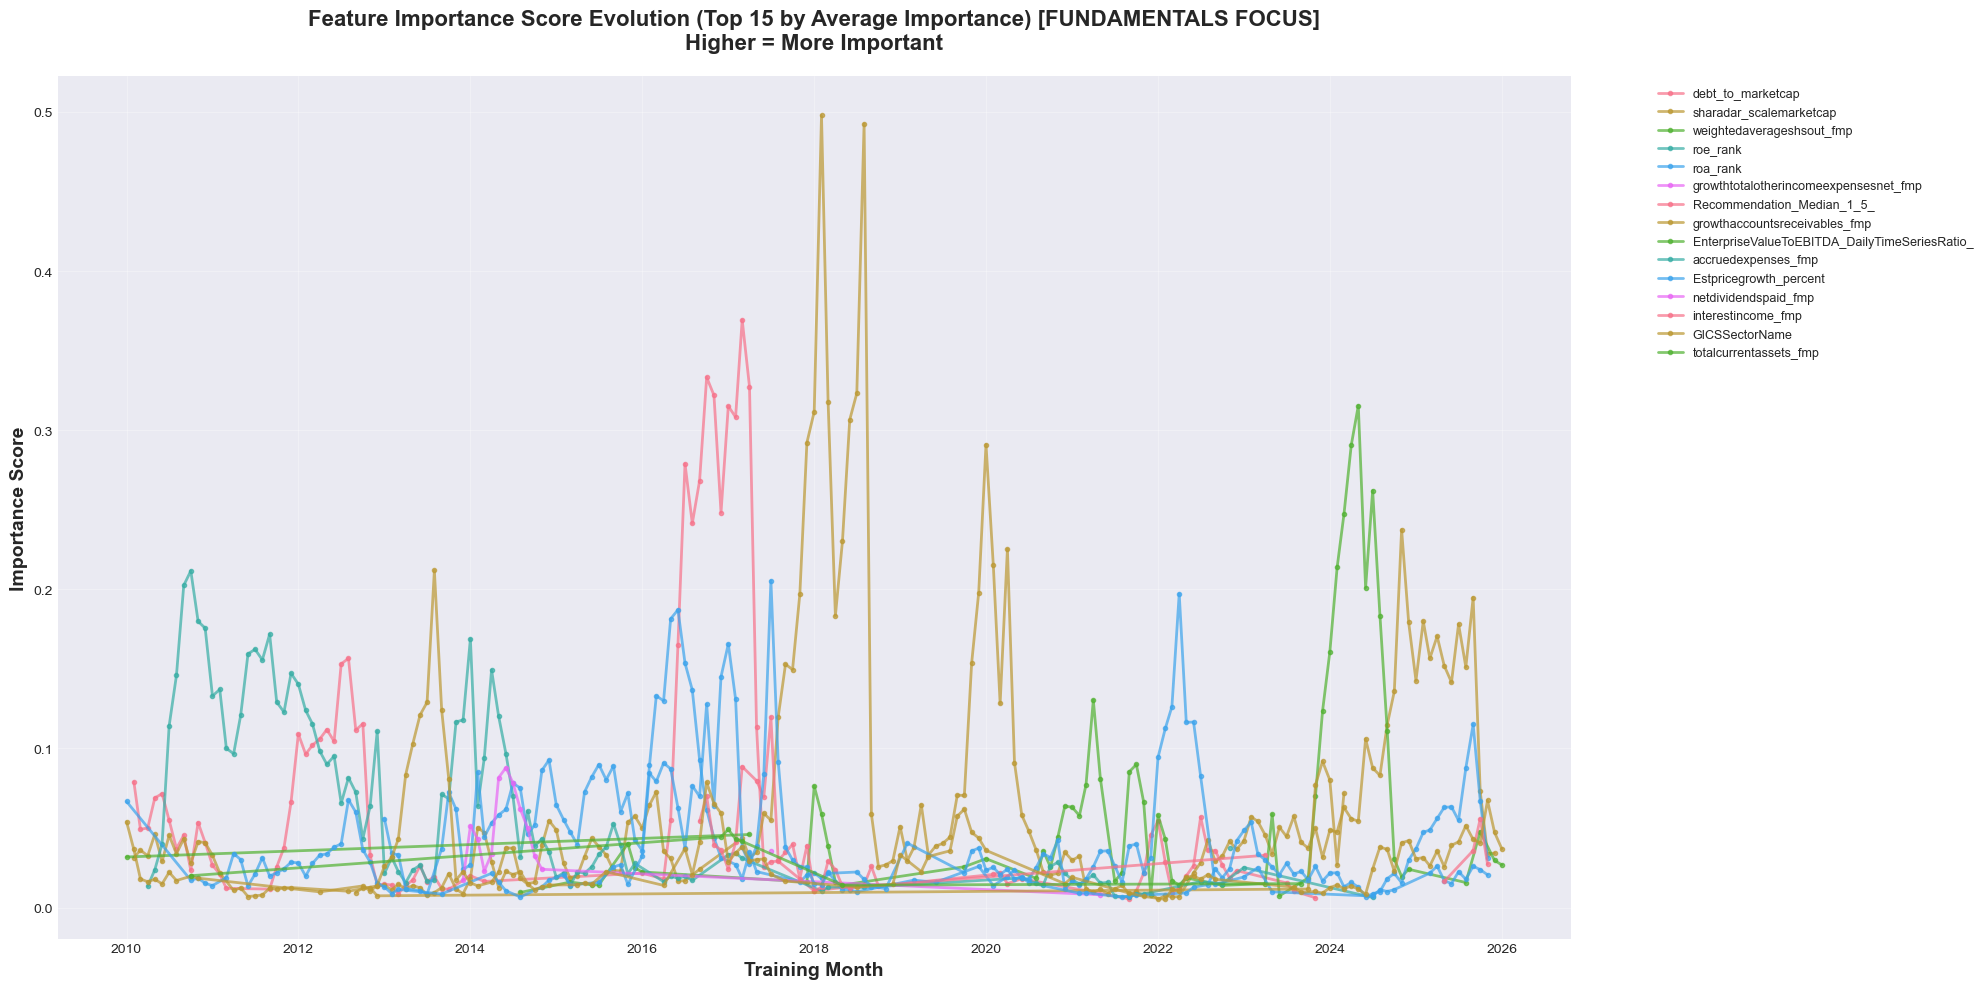


💡 Interpretation:
   • Higher values = Model relies more on this feature
   • Score changes = Feature utility shifts with market conditions


In [234]:
# Get top 15 features by average importance score
N_FEATURES_IMP = 15
avg_importance = df.groupby('Feature')['Importance'].mean().sort_values(ascending=False)
top_importance_features = avg_importance.head(N_FEATURES_IMP).index.tolist()

# Filter data
df_imp = df[df['Feature'].isin(top_importance_features)].copy()
df_imp['MonthDate'] = pd.to_datetime(df_imp['Month'] + '-01')

# Create plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot each feature
for feature in top_importance_features:
    feature_data = df_imp[df_imp['Feature'] == feature].sort_values('MonthDate')
    ax.plot(feature_data['MonthDate'], 
            feature_data['Importance'],
            marker='o',
            markersize=3,
            linewidth=2,
            label=feature,
            alpha=0.7)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Importance Score Evolution (Top {N_FEATURES_IMP} by Average Importance){mode_text}\n' +
             'Higher = More Important',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Higher values = Model relies more on this feature")
print(f"   • Score changes = Feature utility shifts with market conditions")

## 7. Feature Stability Analysis

Quantifies which features have most consistent rankings over time.

In [235]:
# Calculate stability metrics for each feature
stability_metrics = []

for feature in df['Feature'].unique():
    feature_data = df[df['Feature'] == feature]
    
    # Only analyze if feature appears in at least 25% of months
    min_appearances = df['Month'].nunique() * 0.25
    if len(feature_data) < min_appearances:
        continue
    
    metrics = {
        'Feature': feature,
        'Appearances': len(feature_data),
        'Appearance_Pct': (len(feature_data) / df['Month'].nunique()) * 100,
        'Avg_Rank': feature_data['Rank'].mean(),
        'Median_Rank': feature_data['Rank'].median(),
        'Std_Rank': feature_data['Rank'].std(),
        'Min_Rank': feature_data['Rank'].min(),
        'Max_Rank': feature_data['Rank'].max(),
        'Rank_Range': feature_data['Rank'].max() - feature_data['Rank'].min(),
        'Avg_Importance': feature_data['Importance'].mean(),
        'Top10_Count': (feature_data['Rank'] <= 10).sum(),
        'Top20_Count': (feature_data['Rank'] <= 20).sum(),
    }
    
    stability_metrics.append(metrics)

df_stability = pd.DataFrame(stability_metrics)

# Sort by stability (low std_rank = more stable)
df_stability = df_stability.sort_values('Std_Rank')

print("📊 MOST STABLE FEATURES (Low Rank Variance)\n")
print(df_stability.head(20).to_string(index=False))

print("\n" + "="*100 + "\n")

# Sort by average rank (best performers)
df_best = df_stability.sort_values('Avg_Rank').head(20)
print("🏆 BEST AVERAGE PERFORMERS (Consistently Highly Ranked)\n")
print(df_best.to_string(index=False))

📊 MOST STABLE FEATURES (Low Rank Variance)

                                     Feature  Appearances  Appearance_Pct  Avg_Rank  Median_Rank  Std_Rank  Min_Rank  Max_Rank  Rank_Range  Avg_Importance  Top10_Count  Top20_Count
                                  return_20d          141       73.056995  9.290780          8.0  4.251956         2        19          17        0.029233           87          141
                           ev_to_ebitda_rank           51       26.424870 13.196078         13.0  4.275603         6        20          14        0.017463           15           51
                            fcf_to_marketcap           50       25.906736 13.380000         13.0  4.313671         3        20          17        0.018243           13           50
                                  return_10d           77       39.896373 13.077922         14.0  4.388281         3        20          17        0.021416           25           77
                              volatility_10d       

## 8. Monthly Top 5 Features Evolution

Bar chart race style visualization showing top 5 features for each month.

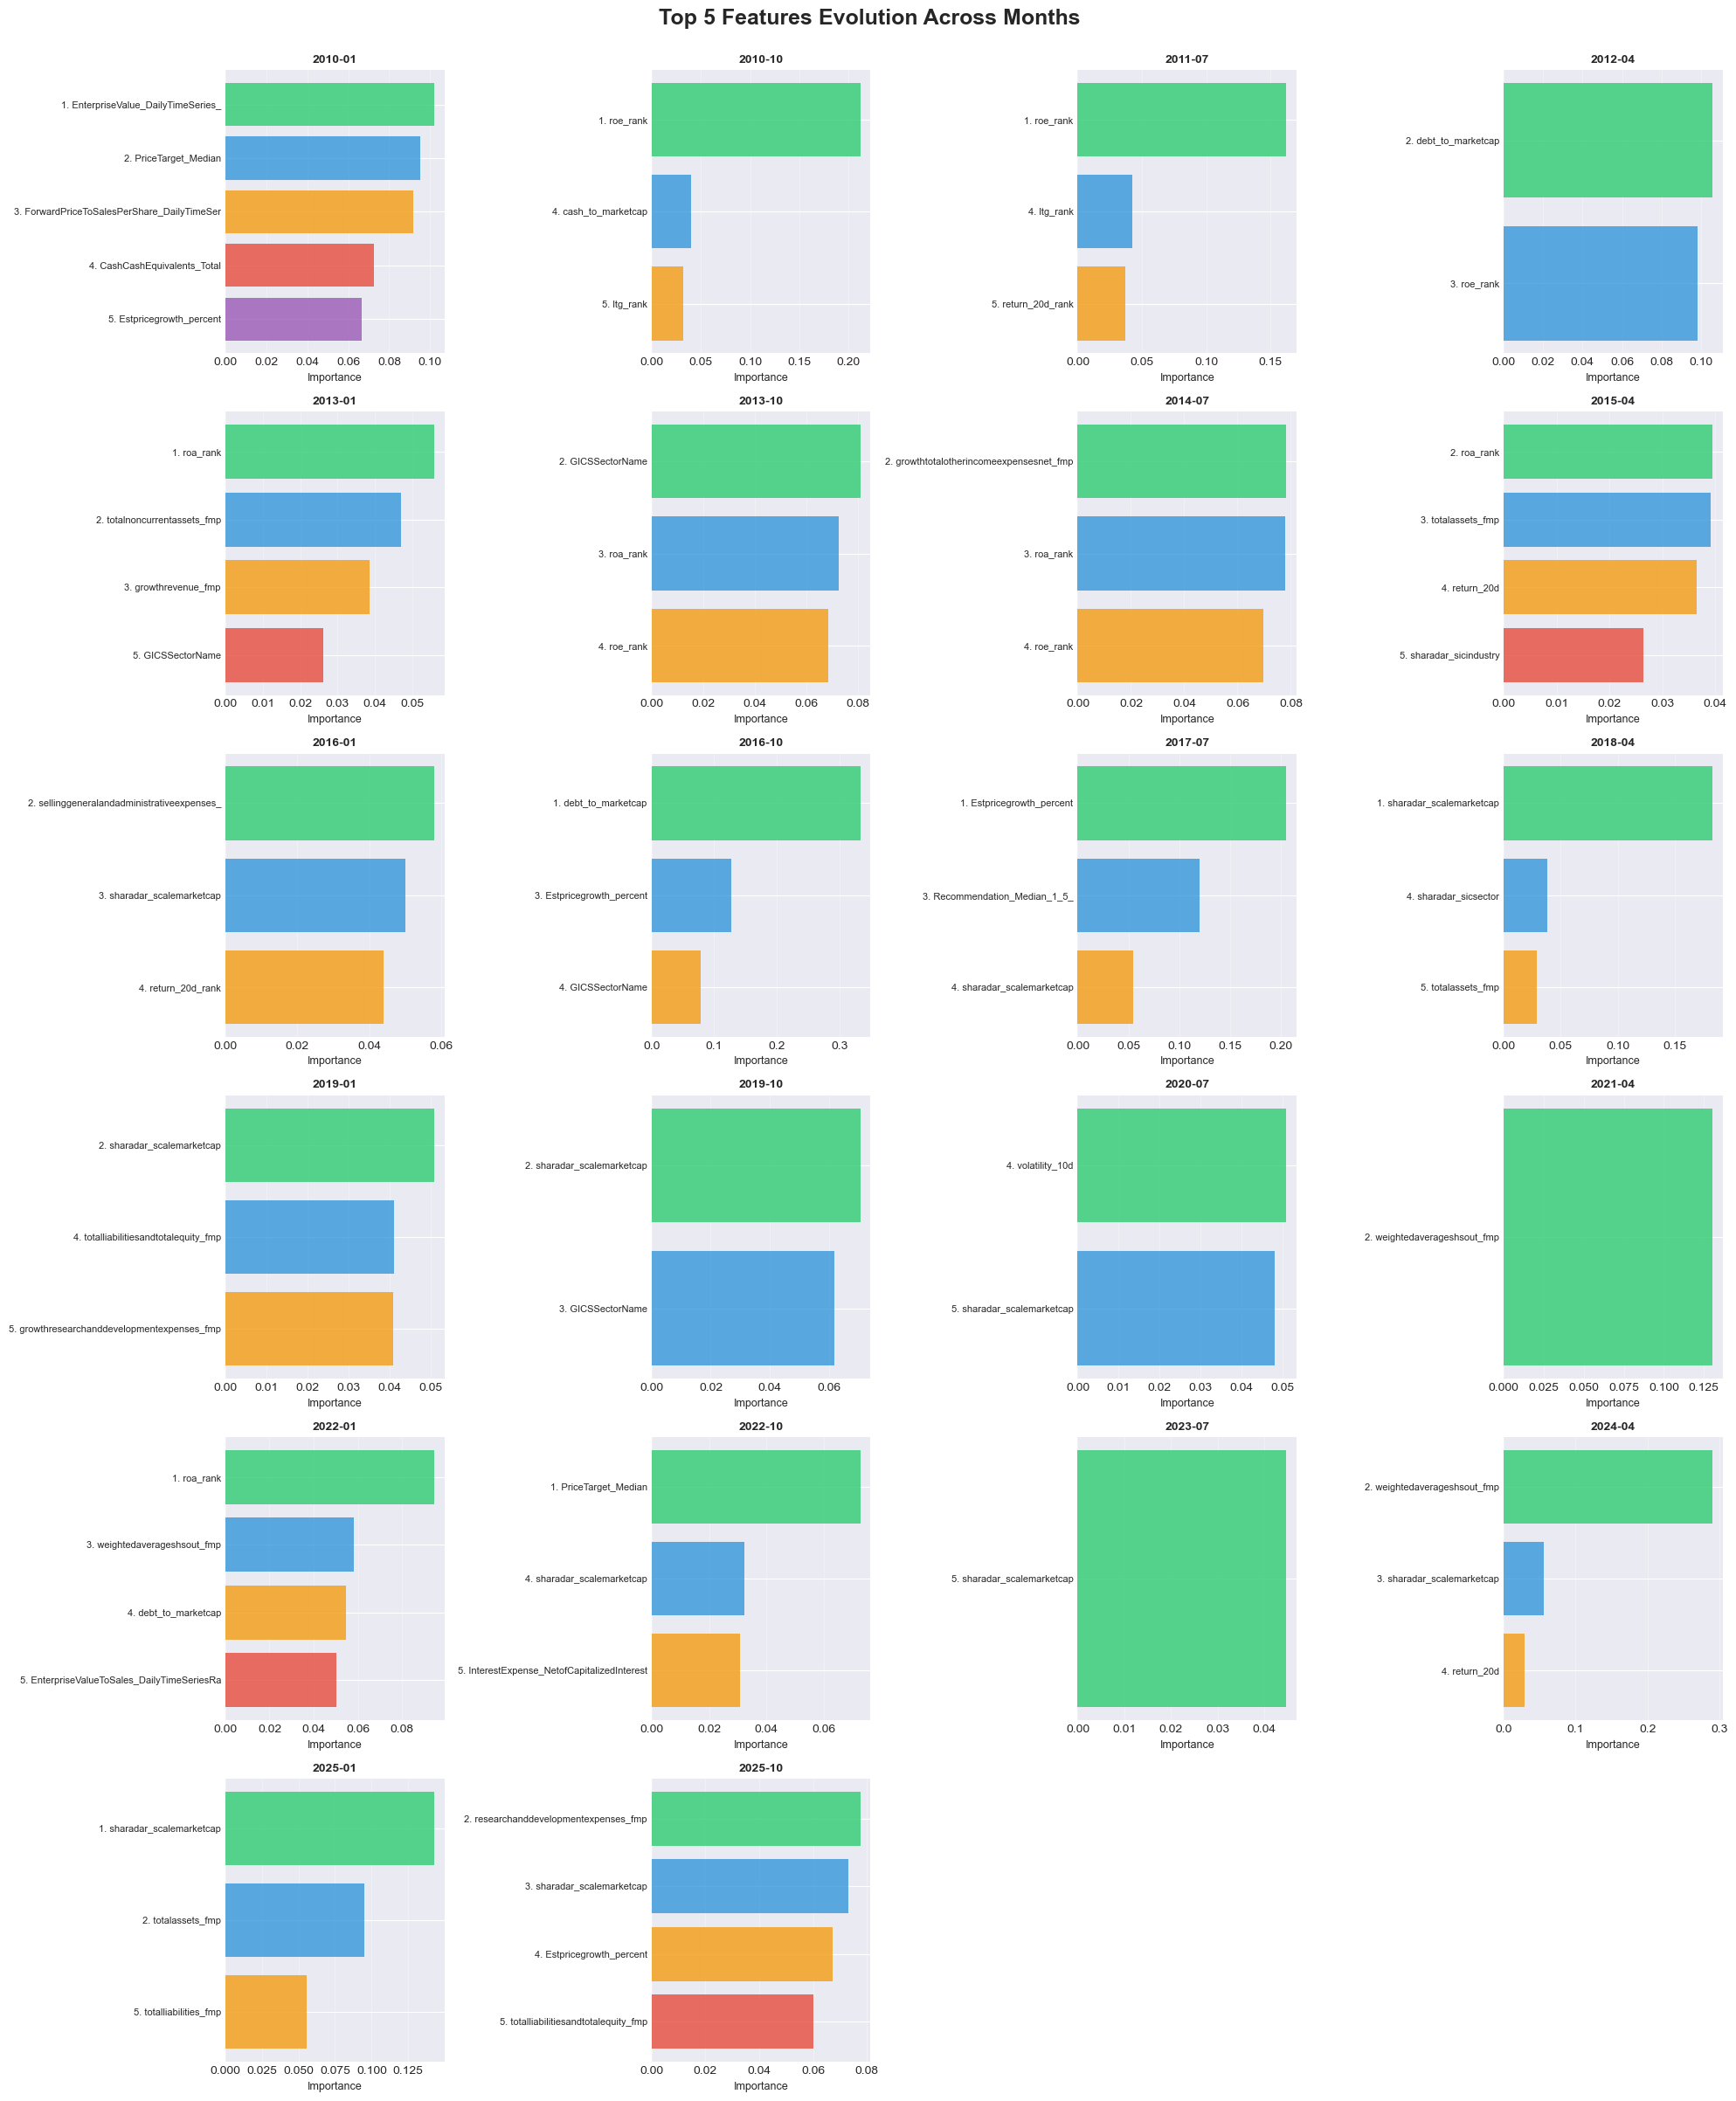


💡 Showing 22 of 193 total months
   Green = Rank 1, Blue = Rank 2, Orange = Rank 3, Red = Rank 4, Purple = Rank 5


In [236]:
# Get top 5 features for each month
top5_per_month = df[df['Rank'] <= 5].copy()

# Get unique months (sample every Nth month if too many)
unique_months = sorted(df['Month'].unique())
sample_interval = max(1, len(unique_months) // 20)  # Show ~20 months max
sampled_months = unique_months[::sample_interval]

# Create subplots
n_months = len(sampled_months)
n_cols = 4
n_rows = (n_months + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten() if n_months > 1 else [axes]

for idx, month in enumerate(sampled_months):
    ax = axes[idx]
    
    # Get top 5 for this month
    month_data = top5_per_month[top5_per_month['Month'] == month].sort_values('Rank')
    
    # Create horizontal bar chart
    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'][:len(month_data)]
    
    ax.barh(range(len(month_data)), 
            month_data['Importance'].values,
            color=colors,
            alpha=0.8)
    
    ax.set_yticks(range(len(month_data)))
    ax.set_yticklabels([f"{rank}. {feat[:40]}" 
                        for rank, feat in zip(month_data['Rank'], month_data['Feature'])],
                       fontsize=8)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f'{month}', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

# Hide unused subplots
for idx in range(len(sampled_months), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Top 5 Features Evolution Across Months', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n💡 Showing {len(sampled_months)} of {len(unique_months)} total months")
print(f"   Green = Rank 1, Blue = Rank 2, Orange = Rank 3, Red = Rank 4, Purple = Rank 5")

## 9. Feature Category Analysis

Group features by type and analyze category importance over time.

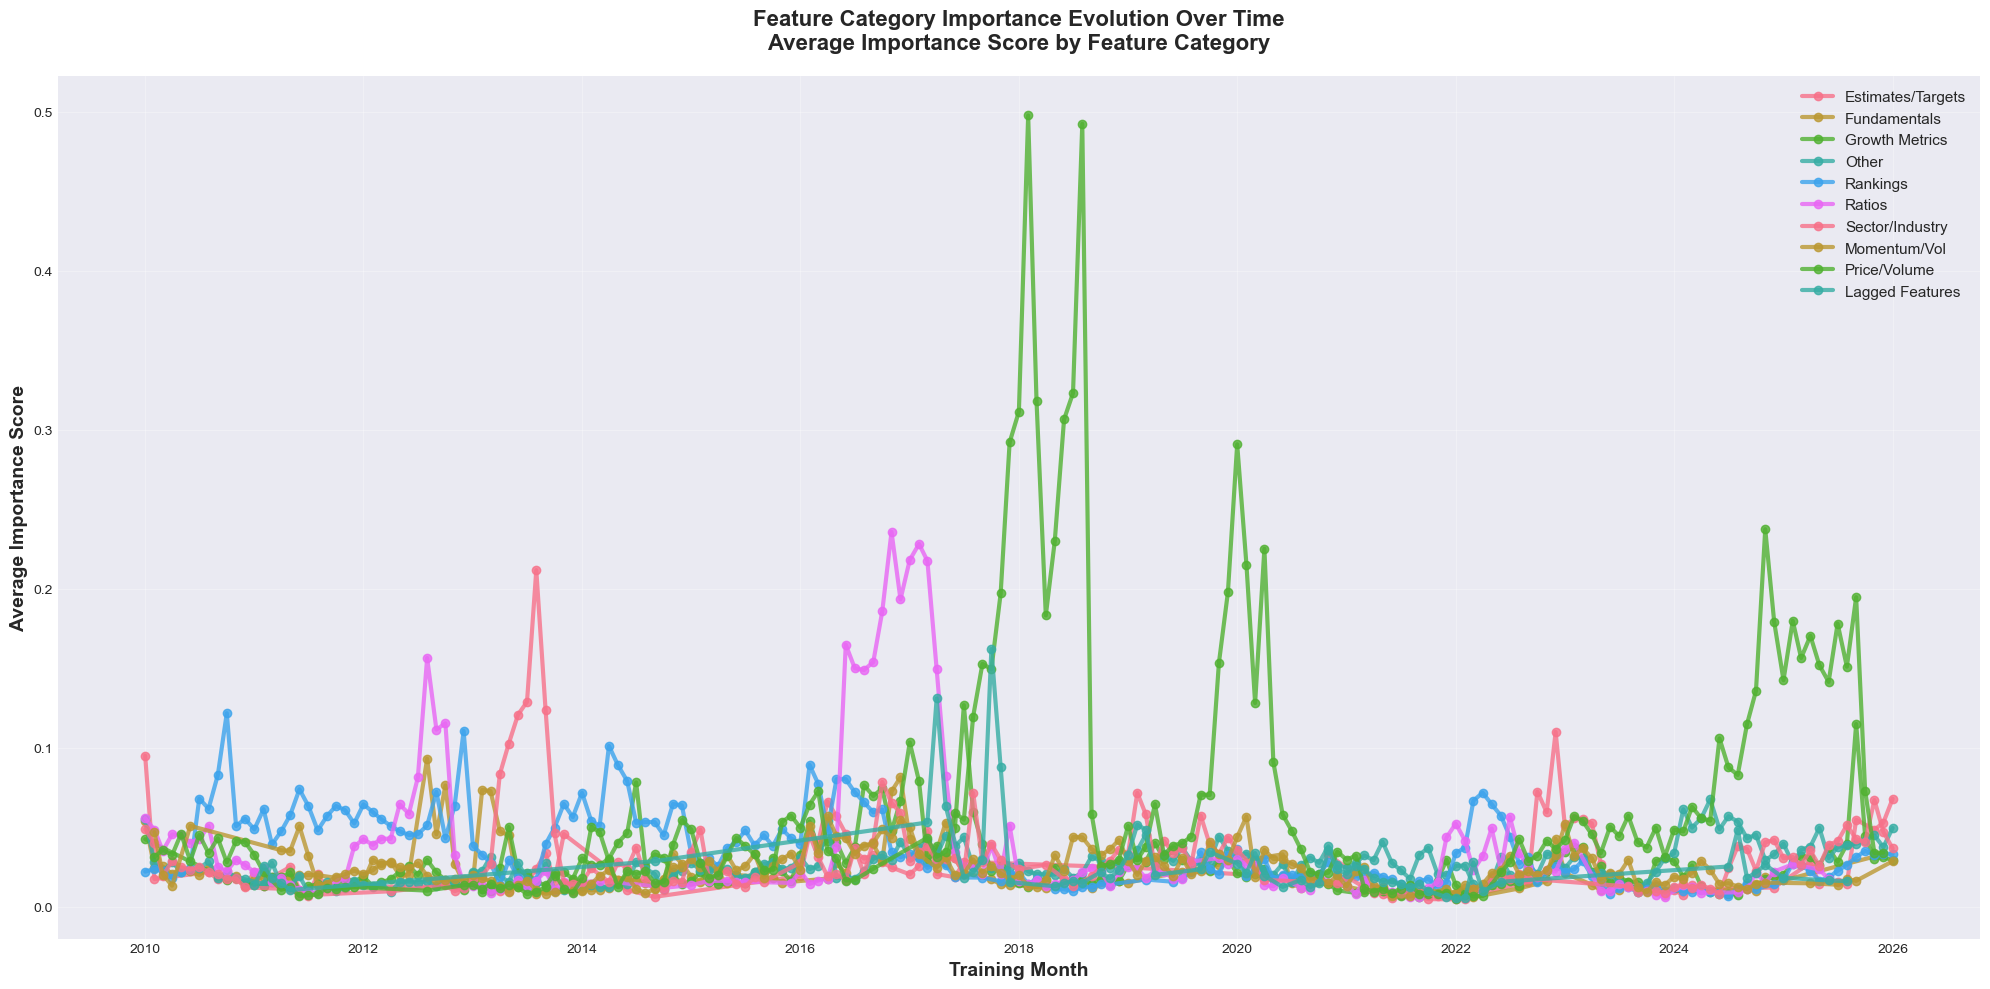


📊 Feature Category Statistics

                   Unique_Features  Avg_Importance  Std_Importance  Avg_Rank  \
Category                                                                       
Price/Volume                     1          0.0668          0.0842    7.3584   
Rankings                         7          0.0377          0.0383   10.1261   
Ratios                          13          0.0366          0.0545   11.4169   
Sector/Industry                  4          0.0297          0.0250   10.9891   
Other                           64          0.0280          0.0283   11.9033   
Estimates/Targets                5          0.0266          0.0213   12.0870   
Lagged Features                  2          0.0265          0.0257   11.5303   
Momentum/Vol                     6          0.0245          0.0134   11.5000   
Growth Metrics                  51          0.0244          0.0218   12.6567   
Fundamentals                    25          0.0241          0.0191   12.9711   

       

In [237]:
def categorize_feature(feature_name):
    """
    Categorize features by type based on name patterns.
    """
    feature_lower = feature_name.lower()
    
    # Categorical features
    if any(x in feature_lower for x in ['sector', 'industry', 'gics']):
        return 'Sector/Industry'
    
    # Lagged features
    if '_lag1' in feature_lower or '_lag2' in feature_lower:
        return 'Lagged Features'
    
    # Ranking features
    if '_rank' in feature_lower or 'rank' in feature_lower:
        return 'Rankings'
    
    # Ratio features
    if '_to_' in feature_lower or 'ratio' in feature_lower:
        return 'Ratios'
    
    # Momentum/volatility
    if any(x in feature_lower for x in ['momentum', 'volatility', 'return']):
        return 'Momentum/Vol'
    
    # Growth features
    if 'growth' in feature_lower:
        return 'Growth Metrics'
    
    # Estimates/targets
    if any(x in feature_lower for x in ['estimate', 'target', 'forward']):
        return 'Estimates/Targets'
    
    # Fundamentals
    if any(x in feature_lower for x in ['earnings', 'revenue', 'ebitda', 'cash', 'debt']):
        return 'Fundamentals'
    
    # Price/volume
    if any(x in feature_lower for x in ['price', 'volume', 'marketcap']):
        return 'Price/Volume'
    
    return 'Other'

# Add category column
df['Category'] = df['Feature'].apply(categorize_feature)

# Calculate average importance by category and month
category_importance = df.groupby(['Month', 'Category'])['Importance'].mean().reset_index()
category_importance['MonthDate'] = pd.to_datetime(category_importance['Month'] + '-01')

# Plot category importance evolution
fig, ax = plt.subplots(figsize=(20, 10))

for category in category_importance['Category'].unique():
    cat_data = category_importance[category_importance['Category'] == category]
    ax.plot(cat_data['MonthDate'],
            cat_data['Importance'],
            marker='o',
            linewidth=3,
            label=category,
            alpha=0.8)

ax.set_title('Feature Category Importance Evolution Over Time\n' +
             'Average Importance Score by Feature Category',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Importance Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Category statistics
print("\n📊 Feature Category Statistics\n")
category_stats = df.groupby('Category').agg({
    'Feature': 'nunique',
    'Importance': ['mean', 'std'],
    'Rank': ['mean', 'median']
}).round(4)
category_stats.columns = ['Unique_Features', 'Avg_Importance', 'Std_Importance', 'Avg_Rank', 'Median_Rank']
category_stats = category_stats.sort_values('Avg_Importance', ascending=False)
print(category_stats)

## 10. Feature Olympics - Yearly Dominance Chart

"Olympics" style visualization showing which features dominated in each year, similar to factor performance charts.

📊 Tracking top 20 features individually across 17 years
   Showing top 12 ranks per year
   Features outside top 20 → aggregated into single gray 'OTHER' box per year
   Boxes per year: min=5, max=10, avg=7.9
   Unique features in legend: 21


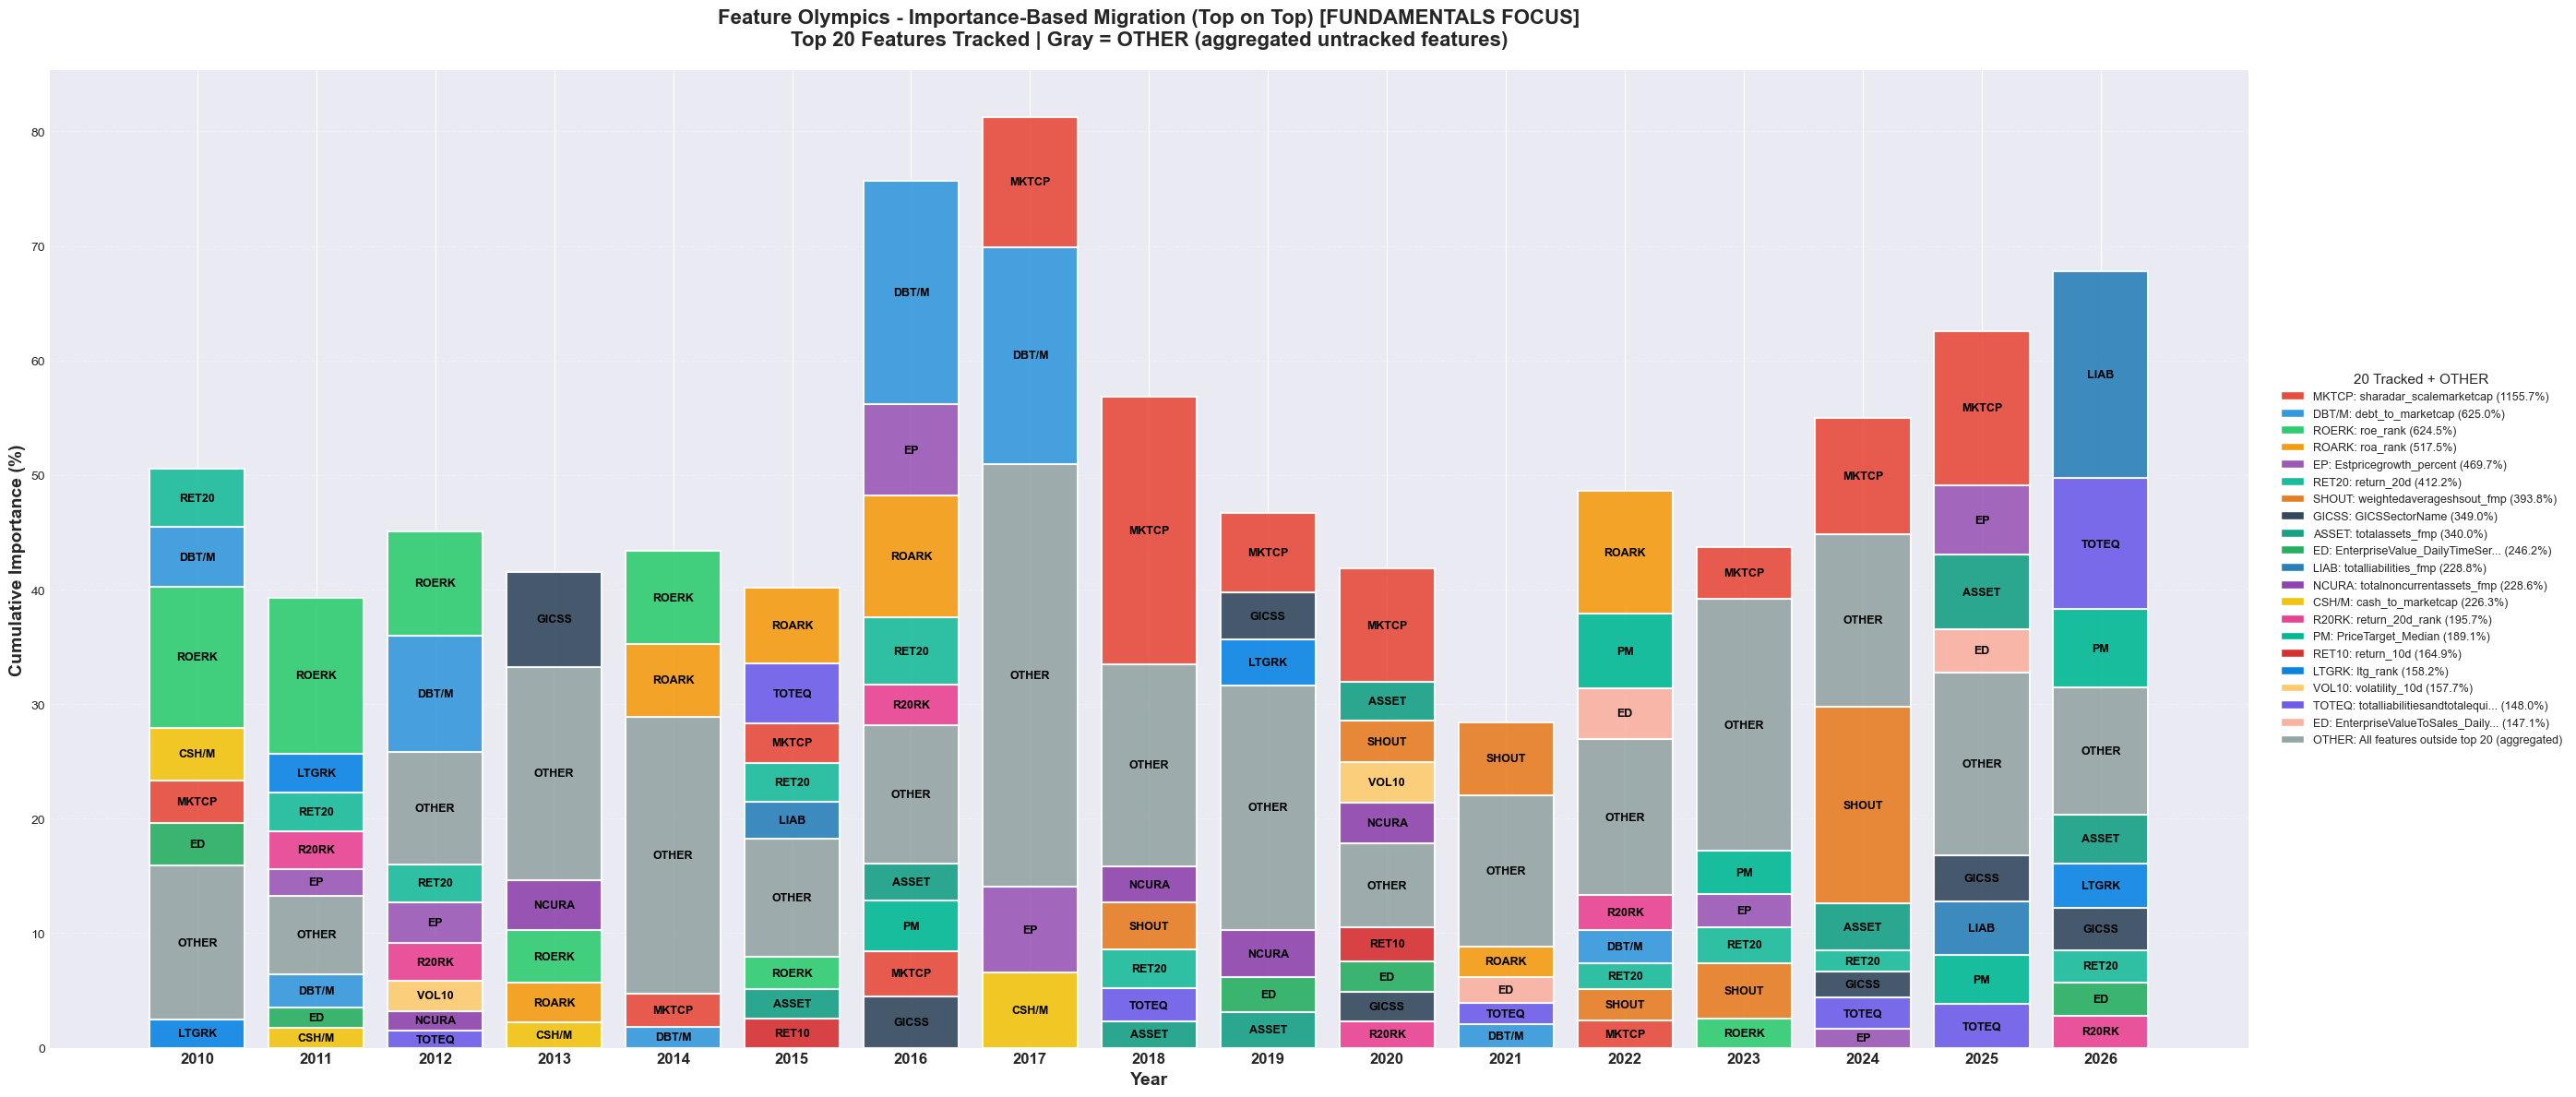

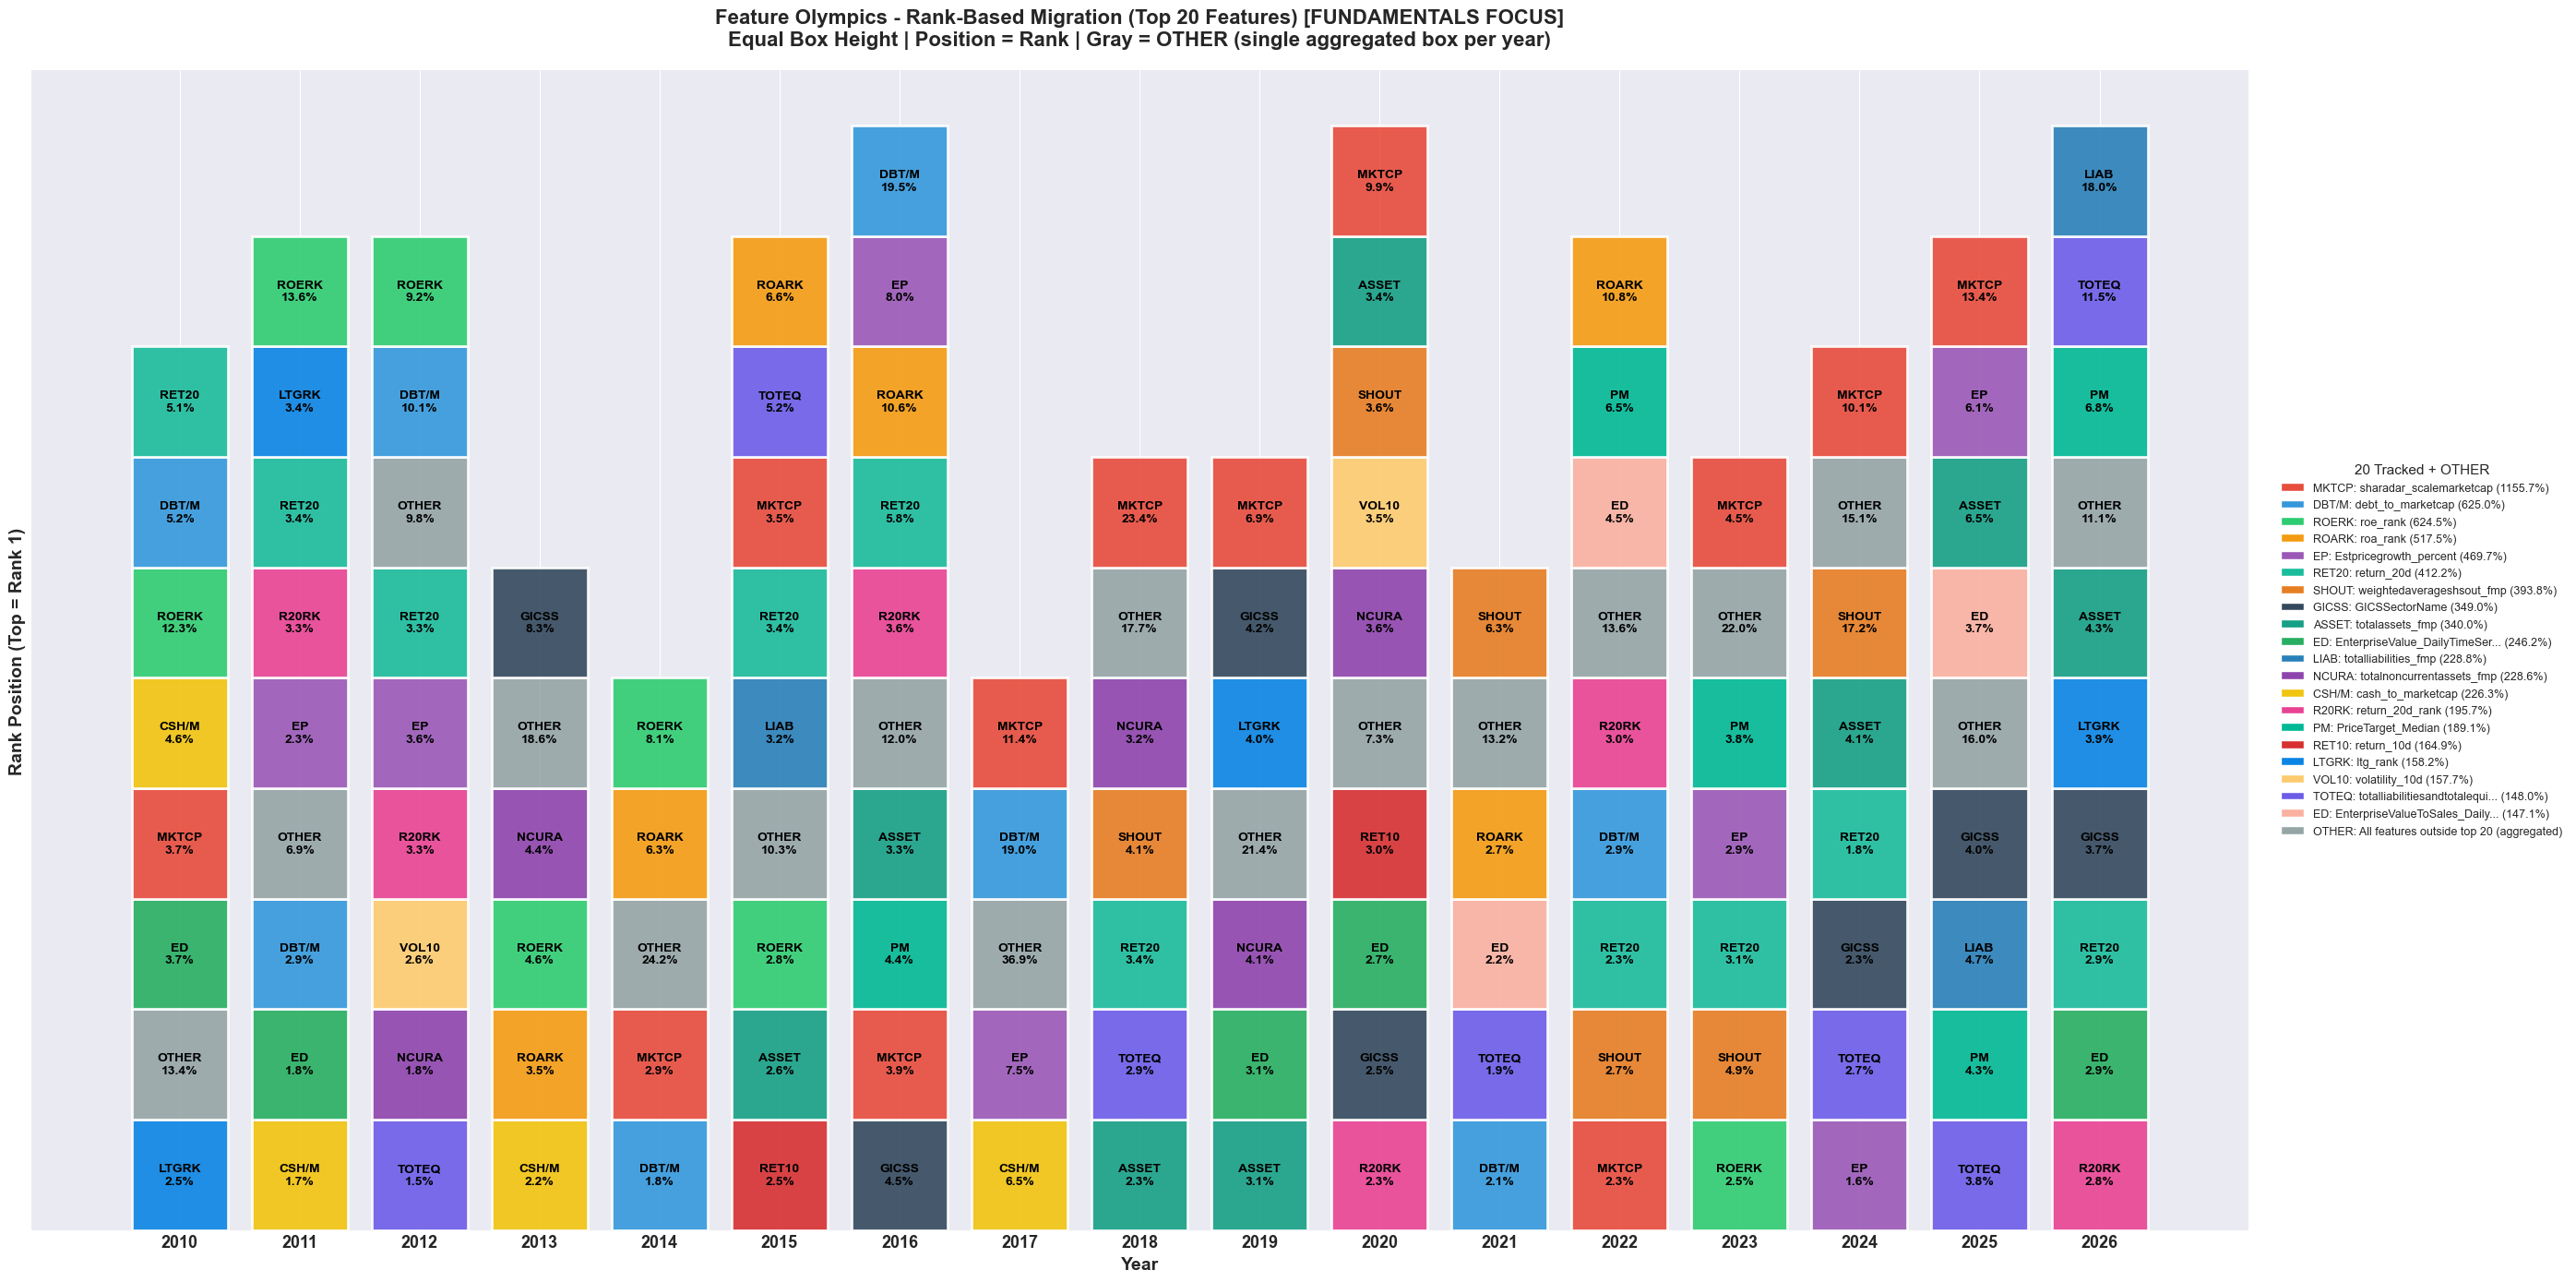


📖 ACRONYM REFERENCE - TOP 20 TRACKED FEATURES
  1. MKTCP  → sharadar_scalemarketcap                            (1155.75%)
  2. DBT/M  → debt_to_marketcap                                  (624.99%)
  3. ROERK  → roe_rank                                           (624.47%)
  4. ROARK  → roa_rank                                           (517.46%)
  5. EP     → Estpricegrowth_percent                             (469.73%)
  6. RET20  → return_20d                                         (412.18%)
  7. SHOUT  → weightedaverageshsout_fmp                          (393.82%)
  8. GICSS  → GICSSectorName                                     (348.95%)
  9. ASSET  → totalassets_fmp                                    (340.01%)
 10. ED     → EnterpriseValue_DailyTimeSeries_                   (246.18%)
 11. LIAB   → totalliabilities_fmp                               (228.76%)
 12. NCURA  → totalnoncurrentassets_fmp                          (228.62%)
 13. CSH/M  → cash_to_marketcap                     

In [238]:
# Feature Olympics: Show top features stacked by year with migration patterns
# Track top 20 features individually, aggregate rest into single "OTHER" box

# Add year column
df['Year'] = df['Month'].str[:4]

# Configuration
N_TOP_RANKS = 12  # Show top 12 ranks per year
N_TRACKED_FEATURES = 20  # Track this many individual features (increased to reduce OTHER boxes)

# Get top N features by total importance across ALL years
feature_total_importance = df.groupby('Feature')['Importance'].sum().sort_values(ascending=False)
top_tracked_features = feature_total_importance.head(N_TRACKED_FEATURES).index.tolist()

print(f"📊 Tracking top {N_TRACKED_FEATURES} features individually across {df['Year'].nunique()} years")
print(f"   Showing top {N_TOP_RANKS} ranks per year")
print(f"   Features outside top {N_TRACKED_FEATURES} → aggregated into single gray 'OTHER' box per year")

# Create meaningful acronyms for tracked features
def create_acronym(feature_name):
    """Generate meaningful 3-5 character acronym for feature."""
    if feature_name == 'OTHER':
        return 'OTHER'
    
    feature_lower = feature_name.lower()
    
    # Custom mappings for common features
    acronym_map = {
        'volatility_20d': 'VOL20',
        'volatility_20d_rank': 'V20RK',
        'volatility_10d': 'VOL10',
        'return_20d': 'RET20',
        'return_20d_rank': 'R20RK',
        'return_10d': 'RET10',
        'sharadar_scalemarketcap': 'MKTCP',
        'roe_rank': 'ROERK',
        'roa_rank': 'ROARK',
        'debt_to_marketcap': 'DBT/M',
        'cash_to_marketcap': 'CSH/M',
        'fcf_to_marketcap': 'FCF/M',
        'ev_to_ebitda_rank': 'EV/EB',
        'totalassets_fmp': 'ASSET',
        'totalliabilities_fmp': 'LIAB',
        'totalliabilitiesandtotalequity_fmp': 'TOTEQ',
        'weightedaverageshsout_fmp': 'SHOUT',
        'estpricegrowth_percent': 'PRGTH',
        'enterprisevalue_dailytimeseries_': 'ENTV',
        'gicssectorname': 'SECTR',
        'pricetarget_median': 'PTGT',
        'ltg_rank': 'LTGRK',
        'totalnoncurrentassets_fmp': 'NCURA',
        'grossprofit_fmp': 'GRPFT',
        'sharadar_sicsector': 'SICSC',
        'sharadar_sicindustry': 'SICIN',
    }
    
    if feature_name in acronym_map:
        return acronym_map[feature_name]
    
    parts = feature_name.replace('_', ' ').split()
    if len(parts) >= 2:
        acronym = ''.join([p[0].upper() for p in parts[:5]])
        return acronym[:5]
    else:
        return feature_name[:5].upper()

feature_acronyms = {feature: create_acronym(feature) for feature in top_tracked_features}
feature_acronyms['OTHER'] = 'OTHER'

# Assign colors to tracked features + gray for OTHER
import matplotlib.cm as cm
import matplotlib.colors as mcolors

distinct_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', 
                   '#1abc9c', '#e67e22', '#34495e', '#16a085', '#27ae60',
                   '#2980b9', '#8e44ad', '#f1c40f', '#e84393', '#00b894',
                   '#d63031', '#0984e3', '#fdcb6e', '#6c5ce7', '#fab1a0']

feature_colors = {}
for i, feature in enumerate(top_tracked_features):
    feature_colors[feature] = distinct_colors[i % len(distinct_colors)]

# Gray for OTHER
feature_colors['OTHER'] = '#95a5a6'

# Build data structure: for each year, aggregate untracked features into single OTHER box
yearly_data = []
years = sorted(df['Year'].unique())

for year in years:
    year_df = df[df['Year'] == year]
    
    # Get top 12 features by rank
    year_feature_ranks = year_df.groupby('Feature')['Rank'].mean().sort_values()
    top_ranks_features = year_feature_ranks.head(N_TOP_RANKS).index.tolist()
    
    # Separate tracked and untracked
    tracked_in_top = []
    untracked_in_top = []
    
    for feature in top_ranks_features:
        feature_year_data = year_df[year_df['Feature'] == feature]
        if len(feature_year_data) > 0:
            avg_rank = feature_year_data['Rank'].mean()
            avg_importance = feature_year_data['Importance'].mean()
            
            if feature in top_tracked_features:
                tracked_in_top.append((feature, avg_rank, avg_importance))
            else:
                untracked_in_top.append((feature, avg_rank, avg_importance))
    
    # Create single OTHER box if there are untracked features
    year_features = tracked_in_top.copy()
    if untracked_in_top:
        # Sum importance and use best rank
        other_total_importance = sum(imp for _, _, imp in untracked_in_top)
        other_best_rank = min(rank for _, rank, _ in untracked_in_top)
        year_features.append(('OTHER', other_best_rank, other_total_importance))
    
    # Sort by rank
    year_features.sort(key=lambda x: x[1])
    
    yearly_data.append({
        'year': year,
        'features': year_features  # (feature, rank, importance)
    })

# Collect features that actually appear for legend
features_in_charts = set()
for year_info in yearly_data:
    for feature, rank, importance in year_info['features']:
        features_in_charts.add(feature)

boxes_per_year = [len(year_info['features']) for year_info in yearly_data]
print(f"   Boxes per year: min={min(boxes_per_year)}, max={max(boxes_per_year)}, avg={sum(boxes_per_year)/len(boxes_per_year):.1f}")
print(f"   Unique features in legend: {len(features_in_charts)}")

# ============================================================================
# VERSION 1: IMPORTANCE-BASED (Height = Importance %)
# ============================================================================

fig, ax = plt.subplots(figsize=(28, 12))

bar_width = 0.8
x_positions = np.arange(len(years))

for year_idx, year_info in enumerate(yearly_data):
    year = year_info['year']
    features = year_info['features']
    
    # Stack bars from BOTTOM TO TOP (reverse order so #1 is on top)
    features_reversed = list(reversed(features))
    
    bottom = 0
    for feature, rank, importance in features_reversed:
        color = feature_colors.get(feature, '#95a5a6')
        bar = ax.bar(year_idx, importance * 100, bar_width, 
                    bottom=bottom,
                    color=color,
                    edgecolor='white',
                    linewidth=1.5,
                    alpha=0.9)
        
        # Add acronym label if segment is large enough
        if importance * 100 > 0.8:
            acronym = feature_acronyms.get(feature, 'OTHER')
            ax.text(year_idx, bottom + (importance * 100) / 2,
                   acronym,
                   ha='center', va='center',
                   fontsize=9, fontweight='bold',
                   color='black')
        
        bottom += importance * 100

# Format chart
ax.set_xticks(x_positions)
ax.set_xticklabels(years, fontsize=12, fontweight='bold', rotation=0)
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Importance (%)', fontsize=14, fontweight='bold')

mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Olympics - Importance-Based Migration (Top on Top){mode_text}\n' +
             f'Top {N_TRACKED_FEATURES} Features Tracked | Gray = OTHER (aggregated untracked features)',
             fontsize=16, fontweight='bold', pad=20)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Create legend for tracked features + OTHER
legend_features = [f for f in top_tracked_features if f in features_in_charts]
if 'OTHER' in features_in_charts:
    legend_features.append('OTHER')

legend_elements = []
for feature in legend_features:
    color = feature_colors[feature]
    acronym = feature_acronyms.get(feature, 'OTHER')
    
    if feature == 'OTHER':
        legend_elements.append(
            plt.Rectangle((0, 0), 1, 1, fc=color, edgecolor='white', linewidth=1,
                         label=f'{acronym}: All features outside top {N_TRACKED_FEATURES} (aggregated)')
        )
    else:
        feature_short = feature[:28] + '...' if len(feature) > 28 else feature
        total_imp = feature_total_importance.get(feature, 0)
        legend_elements.append(
            plt.Rectangle((0, 0), 1, 1, fc=color, edgecolor='white', linewidth=1,
                         label=f'{acronym}: {feature_short} ({total_imp*100:.1f}%)')
        )

ax.legend(handles=legend_elements, 
         loc='center left', 
         bbox_to_anchor=(1.01, 0.5),
         fontsize=9,
         framealpha=0.95,
         ncol=1,
         title=f'{N_TRACKED_FEATURES} Tracked + OTHER',
         title_fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# VERSION 2: RANK-BASED (Equal Height Per Box)
# ============================================================================

fig, ax = plt.subplots(figsize=(28, 14))

bar_width = 0.8
x_positions = np.arange(len(years))

# Equal height per box
SEGMENT_HEIGHT = 1.0

for year_idx, year_info in enumerate(yearly_data):
    year = year_info['year']
    features = year_info['features']
    
    # Stack in reverse order (best rank on top)
    features_reversed = list(reversed(features))
    
    bottom = 0
    for rank_position, (feature, rank, importance) in enumerate(features_reversed):
        color = feature_colors.get(feature, '#95a5a6')
        bar = ax.bar(year_idx, SEGMENT_HEIGHT, bar_width, 
                    bottom=bottom,
                    color=color,
                    edgecolor='white',
                    linewidth=2,
                    alpha=0.9)
        
        # Add acronym + importance percentage
        acronym = feature_acronyms.get(feature, 'OTHER')
        pct = importance * 100
        
        label = f'{acronym}\n{pct:.1f}%'
        
        ax.text(year_idx, bottom + SEGMENT_HEIGHT / 2,
               label,
               ha='center', va='center',
               fontsize=10,
               fontweight='bold',
               color='black')
        
        bottom += SEGMENT_HEIGHT

# Format chart
ax.set_xticks(x_positions)
ax.set_xticklabels(years, fontsize=13, fontweight='bold', rotation=0)
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel(f'Rank Position (Top = Rank 1)', fontsize=14, fontweight='bold')

ax.set_title(f'Feature Olympics - Rank-Based Migration (Top {N_TRACKED_FEATURES} Features){mode_text}\n' +
             f'Equal Box Height | Position = Rank | Gray = OTHER (single aggregated box per year)',
             fontsize=16, fontweight='bold', pad=20)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_yticks([])

ax.legend(handles=legend_elements, 
         loc='center left', 
         bbox_to_anchor=(1.01, 0.5),
         fontsize=9,
         framealpha=0.95,
         ncol=1,
         title=f'{N_TRACKED_FEATURES} Tracked + OTHER',
         title_fontsize=11)

plt.tight_layout()
plt.show()

# Print acronym reference
print("\n" + "="*100)
print(f"📖 ACRONYM REFERENCE - TOP {N_TRACKED_FEATURES} TRACKED FEATURES")
print("="*100)
for i, feature in enumerate(legend_features, 1):
    acronym = feature_acronyms.get(feature, 'OTHER')
    if feature == 'OTHER':
        print(f"{i:3d}. {acronym:6s} → All features outside top {N_TRACKED_FEATURES} (aggregated per year)")
    else:
        total_imp = feature_total_importance.get(feature, 0)
        print(f"{i:3d}. {acronym:6s} → {feature:50s} ({total_imp*100:5.2f}%)")
print("="*100)

# Print summary statistics
print("\n" + "="*100)
print(f"🏆 FEATURE OLYMPICS - TOP {N_TRACKED_FEATURES} MIGRATION ANALYSIS")
print("="*100)

for feature in legend_features[:N_TRACKED_FEATURES]:
    if feature == 'OTHER':
        continue
        
    acronym = feature_acronyms[feature]
    
    # Get importance and rank for first 3 and last 3 years
    early_years = years[:3]
    late_years = years[-3:]
    
    early_importance = []
    late_importance = []
    early_ranks = []
    late_ranks = []
    
    for year_info in yearly_data:
        year = year_info['year']
        year_features = year_info['features']
        
        for f, r, imp in year_features:
            if f == feature:
                if year in early_years:
                    early_importance.append(imp)
                    early_ranks.append(r)
                if year in late_years:
                    late_importance.append(imp)
                    late_ranks.append(r)
                break
    
    avg_early_imp = np.mean(early_importance) * 100 if early_importance else 0
    avg_late_imp = np.mean(late_importance) * 100 if late_importance else 0
    avg_early_rank = np.mean(early_ranks) if early_ranks else 99
    avg_late_rank = np.mean(late_ranks) if late_ranks else 99
    
    change_imp = avg_late_imp - avg_early_imp
    change_rank = avg_early_rank - avg_late_rank
    
    trend = "📈 Rising" if change_imp > 1 else "📉 Falling" if change_imp < -1 else "➡️  Stable"
    
    print(f"{trend:12s} {acronym:6s} {feature:45s} | Imp: {avg_early_imp:5.2f}%→{avg_late_imp:5.2f}% ({change_imp:+5.2f}%) | Rank: {avg_early_rank:4.1f}→{avg_late_rank:4.1f} ({change_rank:+4.1f})")

print("="*100)

## 11. Export Summary Statistics

In [239]:
# Export stability metrics to CSV
mode_suffix = "_fundamentals" if FOCUS_ON_FUNDAMENTALS else "_all"
output_file = feature_importance_file.parent / f"feature_stability_analysis{mode_suffix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df_stability.to_csv(output_file, index=False)

print(f"✅ Stability analysis exported to:")
print(f"   {output_file}")

# Summary
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
print(f"\n📋 ANALYSIS SUMMARY{mode_text}")
print(f"   • Total months analyzed: {df['Month'].nunique()}")
print(f"   • Total unique features: {df['Feature'].nunique()}")
print(f"   • Date range: {df['Month'].min()} to {df['Month'].max()}")
if FOCUS_ON_FUNDAMENTALS:
    print(f"   • Excluded features: {', '.join(EXCLUDED_PRICE_FEATURES)}")
print(f"   • Most stable feature: {df_stability.iloc[0]['Feature']}")
print(f"     - Avg rank: {df_stability.iloc[0]['Avg_Rank']:.1f}")
print(f"     - Std rank: {df_stability.iloc[0]['Std_Rank']:.1f}")
print(f"     - Appears in: {df_stability.iloc[0]['Appearance_Pct']:.1f}% of months")
print(f"\n🎯 Best performer: {df_best.iloc[0]['Feature']}")
print(f"     - Avg rank: {df_best.iloc[0]['Avg_Rank']:.1f}")
print(f"     - Top 10 count: {df_best.iloc[0]['Top10_Count']:.0f} times")

✅ Stability analysis exported to:
   logs/feature_stability_analysis_fundamentals_20260126_153557.csv

📋 ANALYSIS SUMMARY [FUNDAMENTALS FOCUS]
   • Total months analyzed: 193
   • Total unique features: 178
   • Date range: 2010-01 to 2026-01
   • Excluded features: RefPriceClose_lag1, CompanyMarketCap_lag1, CompanyMarketCap_lag1_rank, volatility_20d, volatility_20d_rank
   • Most stable feature: return_20d
     - Avg rank: 9.3
     - Std rank: 4.3
     - Appears in: 73.1% of months

🎯 Best performer: sharadar_scalemarketcap
     - Avg rank: 7.4
     - Top 10 count: 124 times
